In [45]:
!pip install pylatexenc
!pip install qiskit
!pip install qiskit_aer

# Quantum Computing Assignment: Grover's Algorithm with Teleportation

In this assignment, you will create a 12-qubit quantum circuit that implements Grover's search algorithm. The objective is to use Grover's algorithm on the first 4 qubits to search for the state `0010`. After applying the Grover oracle and diffuser once, you will use a quantum teleportation protocol to transfer the state of these 4 qubits, with the help of the next 4 qubits, to the last 4 qubits. Then, you will apply the oracle and diffuser again to the last 4 qubits to search for the same state `0010`. The final result will be simulated using a noisy environment under depolarizing noise.

You are provided with an outline of the circuit that you should build, as shown below:

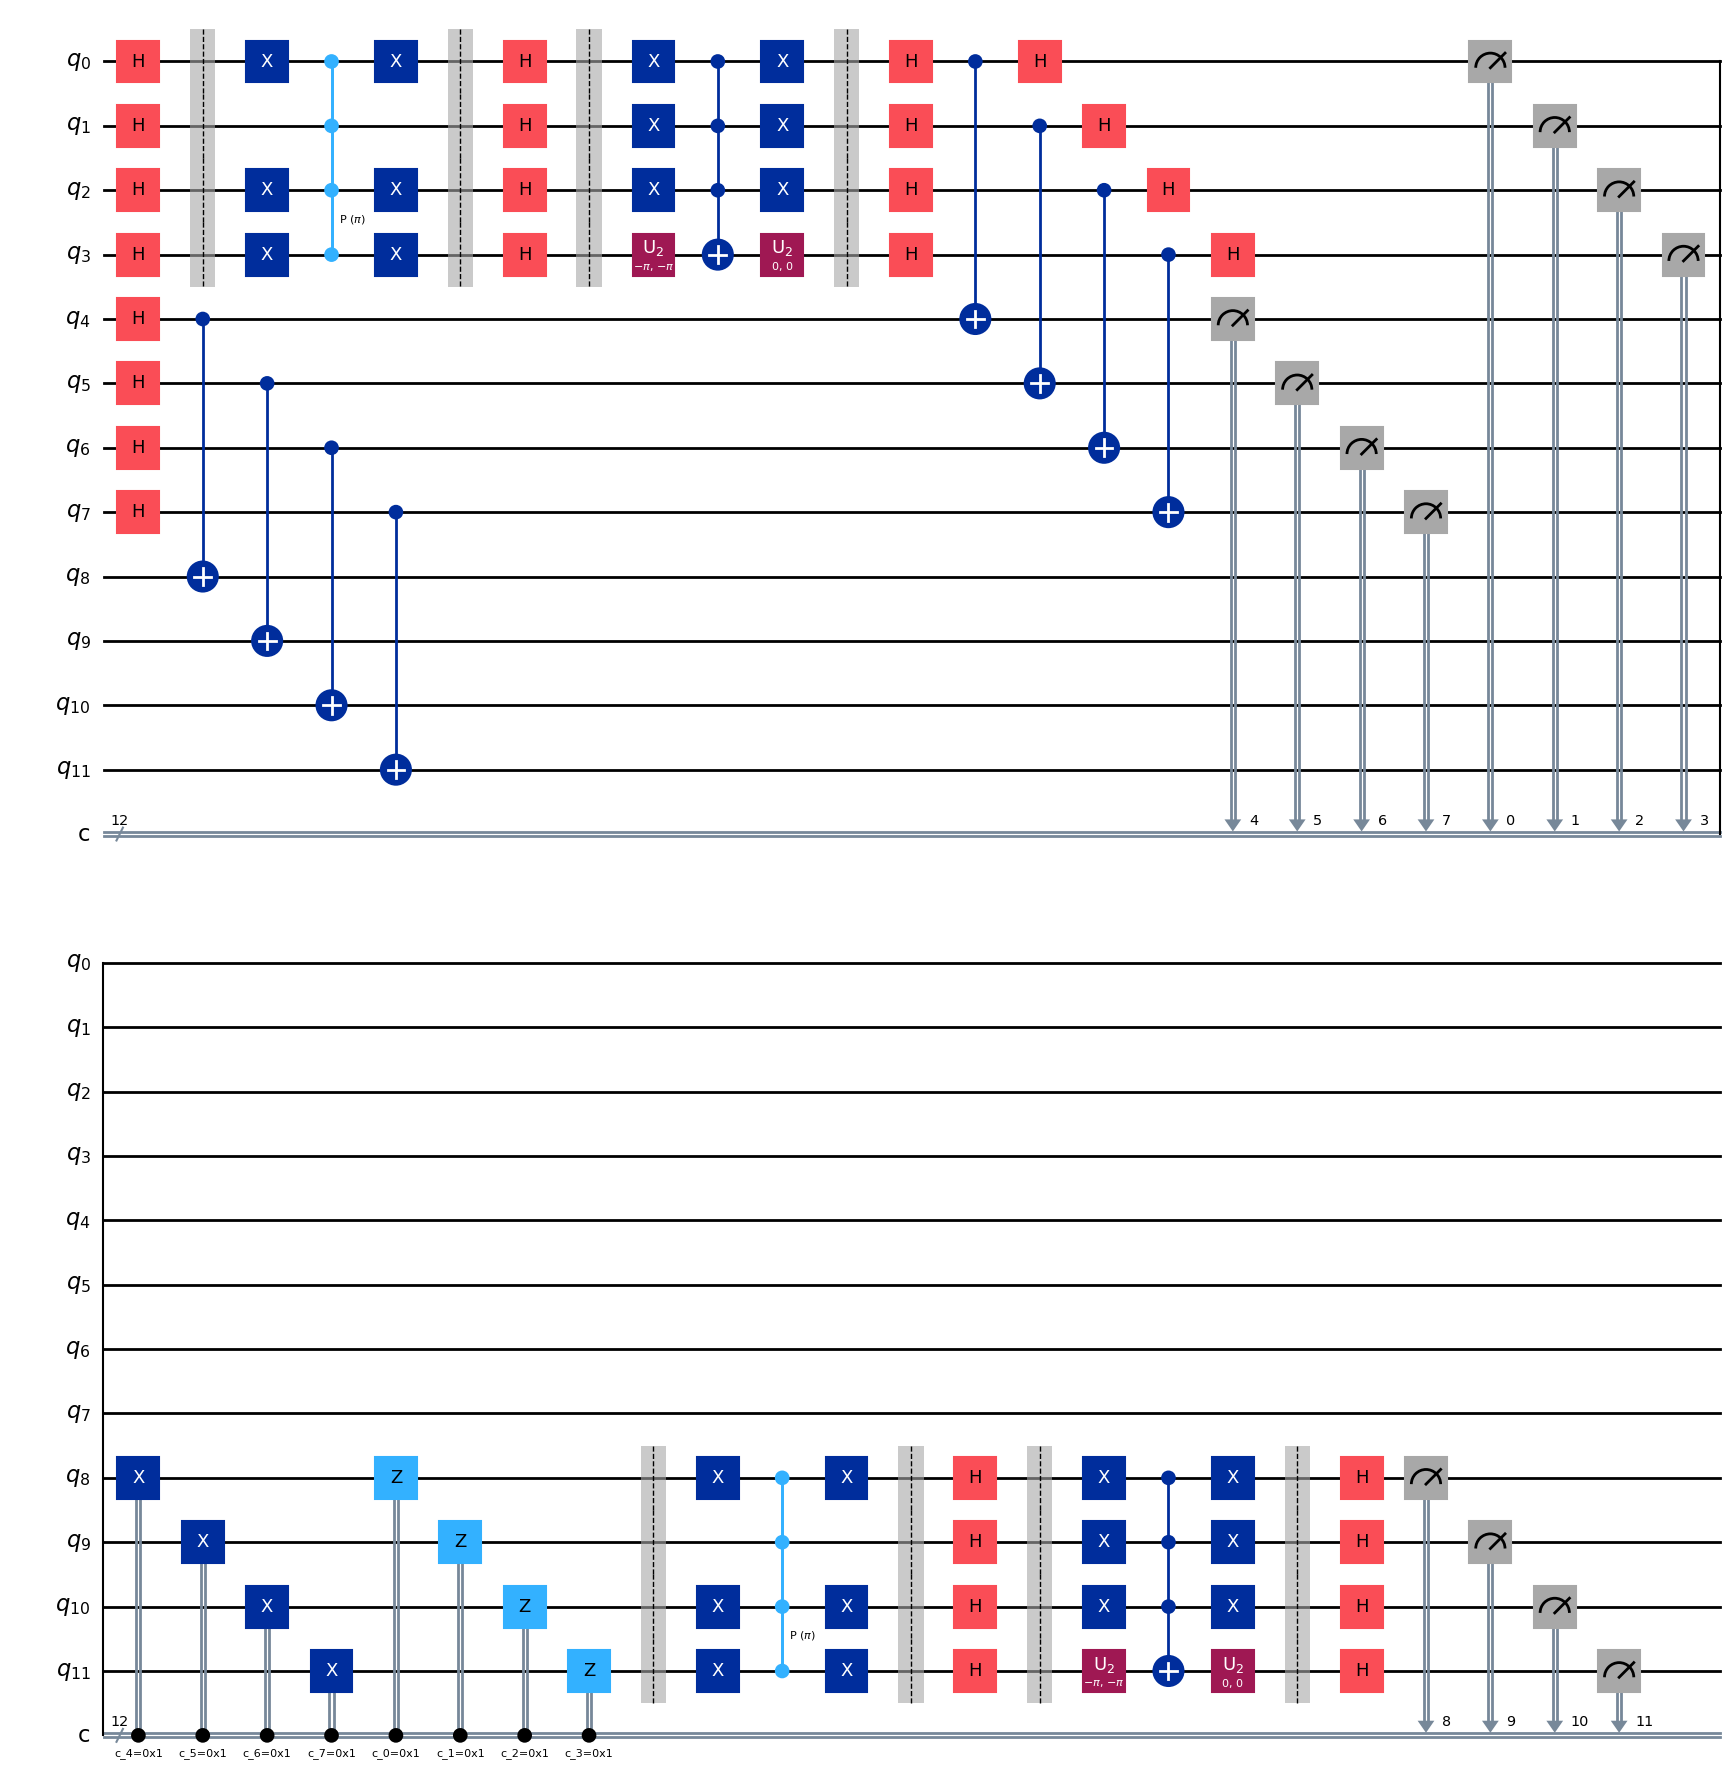

You will use the following steps to complete the task:

### Steps:

1. **Initialize a 12-qubit circuit**.
2. **Use `GroverOperator` to simplify Grover's algorithm**:
    - Import `GroverOperator` from `qiskit.circuit.library`.
    - Use the code below to define the oracle for the state `0010`
```python
mark_state = QuantumCircuit(4)
mark_state.x([0, 2, 3])
mark_state.mcp(pi, list(range(3)), 3)
mark_state.x([0, 2, 3])
```
    - Use `GroverOperator` to automatically generate a Grover operator.
    - Apply the Grover operator on the first 4 qubits once.
3. **Use the next 4 qubits as ancillae** to teleport the state of the first 4 qubits to the last 4 qubits.
    - Apply the quantum teleportation protocol between the first 4 qubits and the last 4 qubits.
4. **Apply the GroverOperator again** on the last 4 qubits to search for `0010`.
5. **Simulate the entire process** using the Aer simulator under depolarizing noise and retrieve the result of the last 4 qubits.

### Noise Model Hint

The noise model should include depolarizing noise for different types of gates with the following probabilities:

- 1-qubit gates: `0.001`
- 2-qubit gates: `0.01`
- 4-qubit gates: `0.1`

You can implement this noise model using Qiskit's noise module as shown below:

```python
# Create depolarizing errors for different gate types
error1 = noise.depolarizing_error(prob_1, 1)
error2 = noise.depolarizing_error(prob_2, 2)
error3 = noise.depolarizing_error(prob_3, 4)

# Add quantum errors according to the gates exist in the circuit
noise_model.add_all_qubit_quantum_error(error1, ['h', 'u2', 'x', 'z'])  # 1-qubit gates
noise_model.add_all_qubit_quantum_error(error2, ['cx'])  # 2-qubit gates
noise_model.add_all_qubit_quantum_error(error3, ['mcp', 'mcx'])  # 4-qubit gates
```

The outcome should be the same if you put 42 as the Aer's seed:

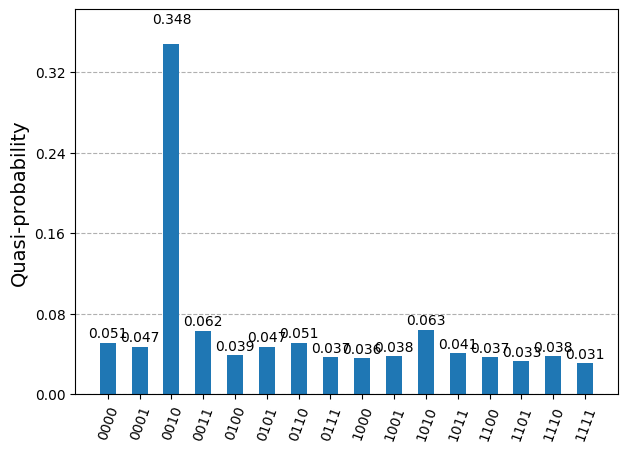

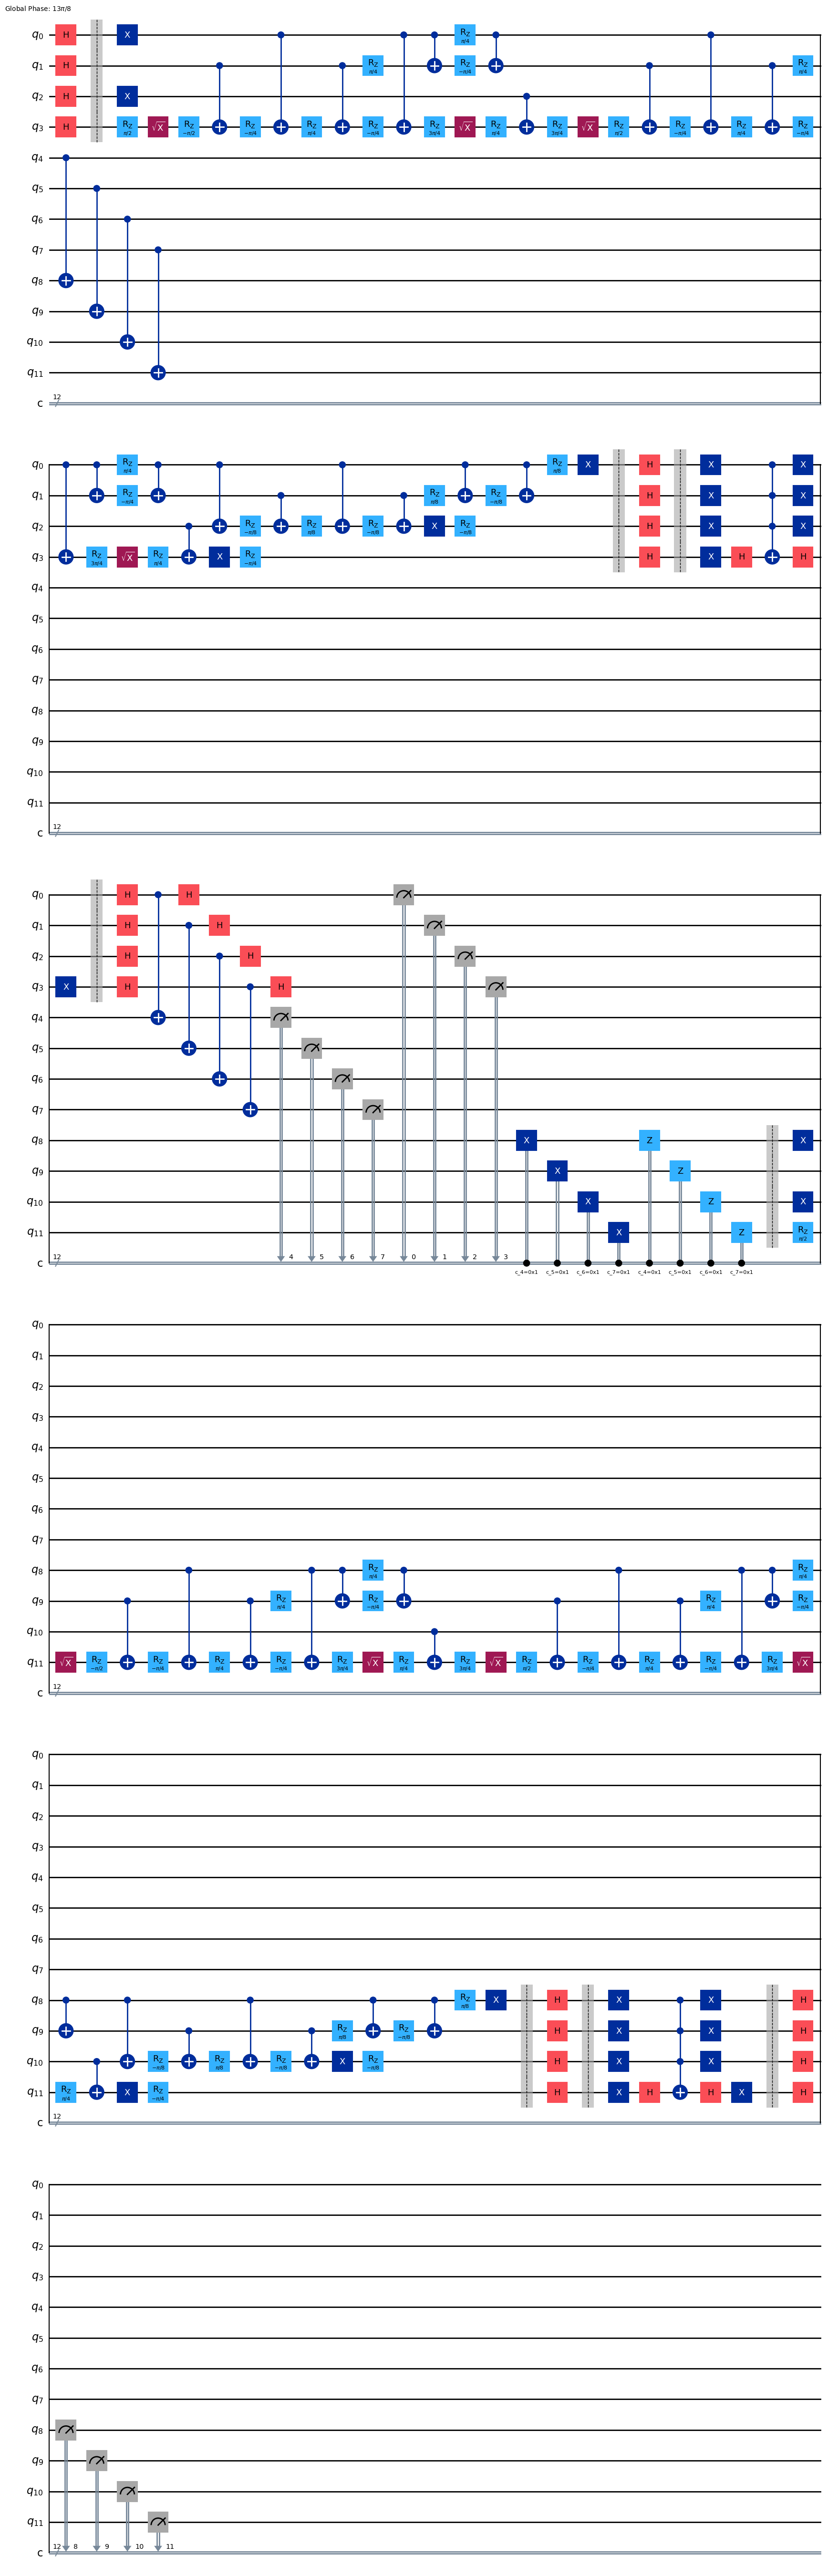

In [49]:
from qiskit import QuantumCircuit
from qiskit import transpile
from math import pi
from qiskit.visualization import plot_distribution
from qiskit.circuit.library import GroverOperator
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator

qc = QuantumCircuit(12, 12)

qc.h([0 ,1 ,2 ,3 ])
qc.barrier(0 ,1 ,2 ,3 )

qc.cx(4,8)
qc.cx(5,9)
qc.cx(6,10)
qc.cx(7,11)

mark_state = QuantumCircuit(4)
mark_state.x([0 ,2 ,3 ])
mark_state.mcp(pi ,[0 ,1 ,2 ] ,3 )
mark_state.x([0 ,2 ,3 ])

GroverOpt = GroverOperator(mark_state ,insert_barriers=True )
qc.append(GroverOpt , [0 ,1 ,2 ,3 ])

simulator_aer = AerSimulator(seed_simulator = 2)

qc.cx(0 ,4 )

qc.h(0)
qc.cx(1 ,5 )

qc.h(1)
qc.cx(2 ,6 )

qc.h(2)
qc.cx(3 ,7 )

qc.h(3)

for i in range(4 ,8 ):
  qc.measure(i ,i )
for i in range(0 ,4 ):
  qc.measure(i ,i )

for i in range(4 ,8 ):
  qc.x(i + 4).c_if(i ,1 )
for i in range(4 ,8 ):
  qc.z(i+4).c_if(i,1)

qc.barrier([8 ,9 ,10 ,11])

qc.append(GroverOpt , [8 ,9 ,10 ,11 ])
qc = transpile(qc ,backend = sim_aer )

for i in range(8 ,12 ):
  qc.measure(i ,i )

qc.draw( output = 'mpl' )

Original counts: {'001100111101': 1, '111111111100': 1, '010001000111': 1, '010100100010': 1, '110100100001': 1, '010001001011': 2, '010101010101': 1, '011000100010': 1, '000100011111': 1, '010110100010': 1, '000111110110': 1, '111111111010': 1, '010001000011': 1, '010000100011': 1, '010101011110': 2, '111011101010': 2, '011100101011': 1, '000110111110': 1, '010101011101': 1, '000110010001': 1, '010001000000': 1, '000100011101': 2, '011000101010': 1, '110111010000': 2, '110011000101': 1, '000100010111': 3, '101010101111': 1, '011110001111': 1, '110100101111': 1, '100100100111': 1, '111011100000': 2, '101110110101': 1, '100010000100': 3, '011000100110': 1, '001100110011': 2, '110100101000': 1, '100001100001': 1, '010110010010': 1, '100001101100': 1, '010100101110': 1, '000100010000': 1, '000100100110': 1, '110101010011': 1, '011001001100': 1, '100100101101': 1, '100101011100': 1, '000100101100': 1, '000100010100': 1, '011101110100': 1, '010010100001': 1, '011100101001': 2, '110100101011

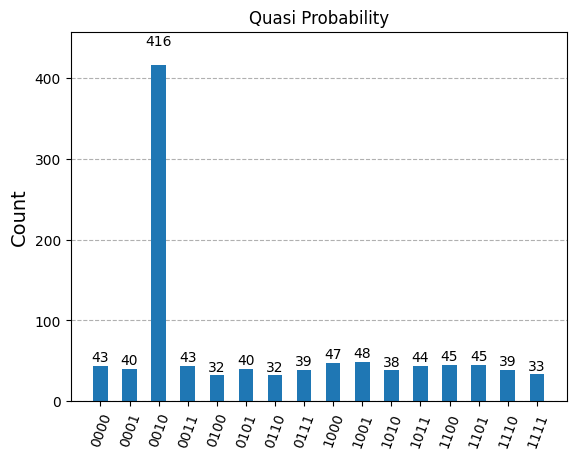

In [50]:
from qiskit_aer import noise
from qiskit.result import marginal_counts
from qiskit.visualization import plot_histogram

er1 = noise.depolarizing_error(0.001, 1 )
er2 = noise.depolarizing_error(0.01, 2 )
er3 = noise.depolarizing_error(0.1, 4 )

noise_model = noise.NoiseModel()
noise_model.add_all_qubit_quantum_error(er1, ['h', 'u2', 'x', 'z'])
noise_model.add_all_qubit_quantum_error(er2, ['cx'])
noise_model.add_all_qubit_quantum_error(er3, ['mcp', 'mcx'])

simulator_aer = AerSimulator( seed_simulator = 42 )
result = simulator_aer.run(qc).result()


counts = result.get_counts(qc)
print("Original counts:", counts)

marginal = marginal_counts(counts, indices=[8, 9, 10, 11])
print("Marginal counts:", marginal)


plot_histogram(marginal, title="Quasi Probability")
